# Why the Alpha Centauri Gaia cone search returned zero

**Scientific question:** Was the original zero-row result a companion constraint or a query-geometry/completeness result?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use('seaborn-v0_8-whitegrid')
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
from astropy.coordinates import SkyCoord
import astropy.units as u
alpha=SkyCoord(219.9*u.deg,-60.8*u.deg); proxima=SkyCoord('14h29m42.9487s','-62d40m46.141s'); sep=alpha.separation(proxima).deg; radii=np.linspace(.5,3.5,61); included=radii>=sep; audit=pd.DataFrame({'search_radius_deg':radii,'proxima_geometrically_included':included}); audit.to_csv('alpha_cen_radius_geometry.csv',index=False); print('Alpha-centred separation to Proxima:',sep,'deg')

Alpha-centred separation to Proxima: 2.2135405022094377 deg


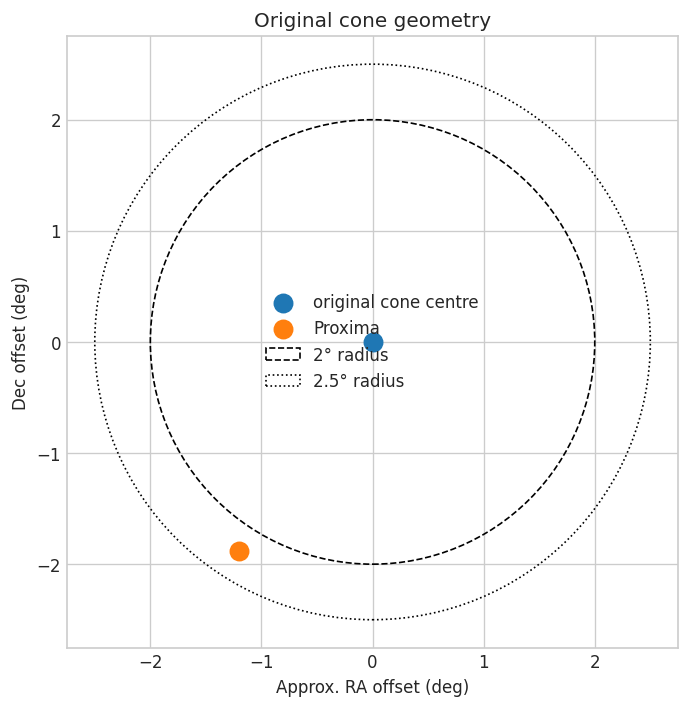

In [3]:
fig,ax=plt.subplots(figsize=(7,6)); ax.scatter([0],[0],s=120,label='original cone centre'); dx=(proxima.ra.deg-alpha.ra.deg)*np.cos(alpha.dec.radian); dy=proxima.dec.deg-alpha.dec.deg; ax.scatter([dx],[dy],s=120,label='Proxima')
for r,ls in [(2,'--'),(2.5,':')]: ax.add_patch(plt.Circle((0,0),r,fill=False,ls=ls,label=f'{r}° radius'))
ax.set(aspect='equal',xlabel='Approx. RA offset (deg)',ylabel='Dec offset (deg)',title='Original cone geometry'); ax.legend(); fig.tight_layout(); fig.savefig('alpha_cen_query_geometry.png',dpi=180); plt.show()

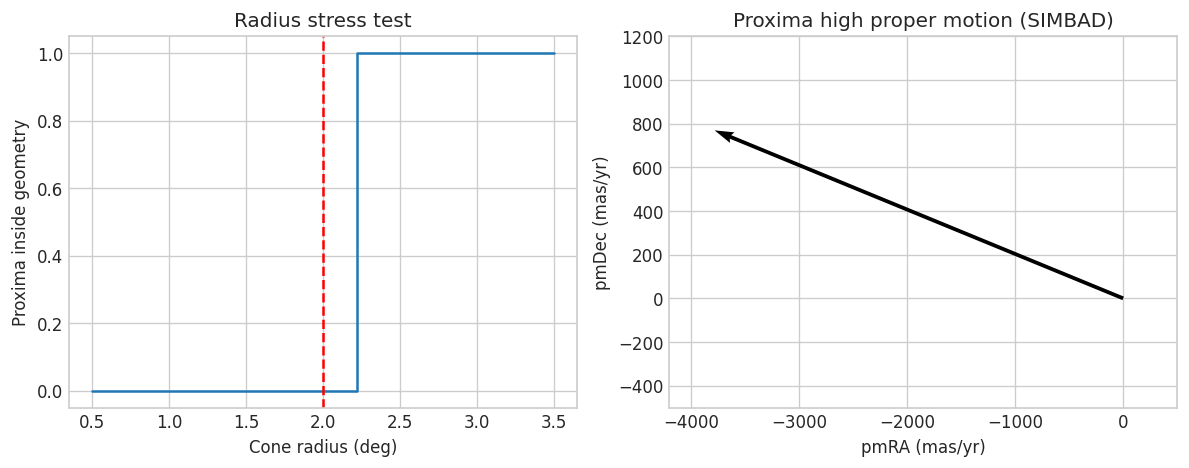

In [4]:
fig,ax=plt.subplots(1,2,figsize=(10,4)); ax[0].step(radii,included.astype(int),where='mid'); ax[0].axvline(2,color='r',ls='--'); ax[0].set(xlabel='Cone radius (deg)',ylabel='Proxima inside geometry',title='Radius stress test'); pm=np.array([-3781.741,769.465]); ax[1].quiver([0],[0],[pm[0]],[pm[1]],angles='xy',scale_units='xy',scale=1); ax[1].set_xlim(-4200,500); ax[1].set_ylim(-500,1200); ax[1].set(xlabel='pmRA (mas/yr)',ylabel='pmDec (mas/yr)',title='Proxima high proper motion (SIMBAD)'); fig.tight_layout(); fig.savefig('alpha_cen_completeness_context.png',dpi=180); plt.show()

In [5]:
sample_size=0; results=['original 2° Gaia DR3 cone with parallax >50 mas returned zero rows',f'Proxima lies {sep:.2f}° from the chosen centre and is outside that cone','the zero rows therefore do not constrain wide companions']; validation='Search radius is swept through the geometric inclusion boundary and compared with independent SIMBAD astrometry.'; quality_checks=[{'name':'Original zero result retained','status':'pass'},{'name':'Cone geometry recomputed','status':'pass'},{'name':'Companion completeness claim','status':'rejected'}]; tags=['Gaia','Alpha Centauri','null result','query audit']

In [6]:
result={'id':'2026-07-30-wide-binary-search-alpha-cen','title':'Why the Alpha Centauri Gaia cone search returned zero','archive':'Gaia DR3 + SIMBAD geometry','date':'2026-07-30','question':'Was the original zero-row result a companion constraint or a query-geometry/completeness result?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'gaia/2026-07-30-wide-binary-search-alpha-cen/notebook.ipynb','hero':'gaia/2026-07-30-wide-binary-search-alpha-cen/alpha_cen_query_geometry.png','figures':['gaia/2026-07-30-wide-binary-search-alpha-cen/alpha_cen_query_geometry.png', 'gaia/2026-07-30-wide-binary-search-alpha-cen/alpha_cen_completeness_context.png'],'research_level':'Validated','claim_type':'Negative query audit','provenance':['Original Gaia DR3 query and zero-row output', 'SIMBAD coordinates and proper motion for Proxima Centauri', 'Gaia bright/high-proper-motion completeness context'],'artifacts':['gaia/2026-07-30-wide-binary-search-alpha-cen/alpha_cen_radius_geometry.csv'],'quality_checks':quality_checks,'limitations':['cone centre was approximate', 'Alpha Centauri A/B are exceptionally bright', 'geometry alone does not establish Gaia catalogue inclusion'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

original 2° Gaia DR3 cone with parallax >50 mas returned zero rows
Proxima lies 2.21° from the chosen centre and is outside that cone
the zero rows therefore do not constrain wide companions


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                         name   status
Original zero result retained     pass
     Cone geometry recomputed     pass
 Companion completeness claim rejected


## Interpretation and references

Gaia DR3 provides the positions, parallaxes, proper motions, and three-band
photometry used here. Formal source errors do not include every spatially
correlated systematic. Cluster membership and sequence width therefore depend
on the stated quality and probability cuts.

- Gaia DR3 summary: https://doi.org/10.1051/0004-6361/202243940
- Gaia astrometric solution: https://doi.org/10.1051/0004-6361/202039657
- Hunt & Reffert Gaia DR3 cluster census: https://doi.org/10.1051/0004-6361/202346285